# LSTM Price Prediction Testing
Testing LSTM model on S&P 500 daily data

**Workflow:**
1. Load 2023-2024 data for training
2. Train LSTM model once
3. Test on each month of 2024-2025
4. Visualize predictions vs actual prices

In [3]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Import your modules
from Data_Handling import get_data_auto
from LSTM_Price_Predictor import LSTMPricePredictor

## 1. Configuration & Data Loading

In [4]:
# Experiment parameters
SYMBOL = "SPY"  # S&P 500 ETF
TIMEFRAME_UNIT = "Day"
MULTIPLIER = 1

# Training period
TRAIN_START = "2023-01-01"
TRAIN_END = "2024-12-31"

# Testing period
TEST_START = "2024-01-01"
TEST_END = "2025-12-31"

# Model parameters
LOOKBACK_WINDOW = 100
PREDICTION_HORIZON = 10
LSTM_UNITS = 50
NUM_LAYERS = 2
DROPOUT = 0.2
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 0.001
PREDICTION_MODE = 'recursive'  # or 'direct'

# Model persistence
MODEL_NAME = f"lstm_{SYMBOL}_{TRAIN_START}_{TRAIN_END}"
RETRAIN = False  # Set to True to force retraining

In [5]:
# Load training data
print(f"Loading training data: {TRAIN_START} to {TRAIN_END}")
train_data = get_data_auto(SYMBOL, start=TRAIN_START, end=TRAIN_END, 
                           timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTraining data shape: {train_data.shape}")
print(f"Date range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Number of trading days: {len(train_data)}")
train_data.head()

Loading training data: 2023-01-01 to 2024-12-31

Training data shape: (501, 5)
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00
Number of trading days: 501

Training data shape: (501, 5)
Date range: 2023-01-03 05:00:00+00:00 to 2024-12-30 05:00:00+00:00
Number of trading days: 501


field,Open,High,Low,Close,Volume
timestamp,,,,,
2023-01-03 05:00:00+00:00,369.481541,371.461746,363.194858,366.069061,74850700.0
2023-01-04 05:00:00+00:00,368.337622,370.933050,365.280805,368.895172,85934100.0
2023-01-05 05:00:00+00:00,366.934202,367.049549,364.088865,364.684845,76970500.0
2023-01-06 05:00:00+00:00,367.789729,374.172545,364.713697,373.047852,104189600.0
2023-01-09 05:00:00+00:00,375.249150,378.450180,372.653751,372.836365,73978100.0


In [6]:
# Load testing data
print(f"Loading testing data: {TEST_START} to {TEST_END}")
test_data = get_data_auto(SYMBOL, start=TEST_START, end=TEST_END,
                          timeframe_unit=TIMEFRAME_UNIT, multiplier=MULTIPLIER)

print(f"\nTesting data shape: {test_data.shape}")
print(f"Date range: {test_data.index[0]} to {test_data.index[-1]}")
print(f"Number of trading days: {len(test_data)}")
test_data.head()

Loading testing data: 2024-01-01 to 2025-12-31

Testing data shape: (501, 5)
Date range: 2024-01-02 05:00:00+00:00 to 2025-12-30 05:00:00+00:00
Number of trading days: 501


field,Open,High,Low,Close,Volume
timestamp,,,,,
2024-01-02 05:00:00+00:00,460.769298,462.242879,459.139573,461.247467,123623700.0
2024-01-03 05:00:00+00:00,459.080980,459.822655,456.875522,457.480560,103585900.0
2024-01-04 05:00:00+00:00,457.002371,459.598202,455.782526,456.006989,84232200.0
2024-01-05 05:00:00+00:00,456.211943,459.090787,455.177517,456.631592,86118900.0
2024-01-08 05:00:00+00:00,457.129257,463.296796,457.002389,463.150421,74879100.0


## 2. Model Training (or Loading)

In [7]:
# Initialize model
predictor = LSTMPricePredictor(
    lookback_window=LOOKBACK_WINDOW,
    prediction_horizon=PREDICTION_HORIZON,
    lstm_units=LSTM_UNITS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    prediction_mode=PREDICTION_MODE,
    verbose=1
)

print(f"Model configuration:")
print(f"  Lookback window: {LOOKBACK_WINDOW} candles")
print(f"  Prediction horizon: {PREDICTION_HORIZON} candles")
print(f"  LSTM units: {LSTM_UNITS}")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Prediction mode: {PREDICTION_MODE}")

Model configuration:
  Lookback window: 100 candles
  Prediction horizon: 10 candles
  LSTM units: 50
  Layers: 2
  Prediction mode: recursive


In [8]:
# Train or load model
import os

model_path = os.path.join('models', f"{MODEL_NAME}.keras")

if os.path.exists(model_path) and not RETRAIN:
    print(f"\n{'='*60}")
    print("Loading existing model...")
    print(f"{'='*60}")
    predictor.load_model(MODEL_NAME)
else:
    print(f"\n{'='*60}")
    print("Training new model...")
    print(f"{'='*60}")
    predictor.fit(train_data, validation_split=0.2, early_stopping_patience=10)
    
    # Save the trained model
    print(f"\nSaving model as '{MODEL_NAME}'...")
    predictor.save_model(MODEL_NAME)

print("\nModel ready for predictions!")


Training new model...
Computing returns from 501 candles...
Creating sequences (lookback=100, horizon=10)...
Generated 392 training sequences
Input shape: (392, 100, 5), Output shape: (392, 10)
Building LSTM model...
Model parameters: 31,451
Training model...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - loss: 0.8866 - mae: 0.7183 - val_loss: 0.7845 - val_mae: 0.6400
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - loss: 0.8866 - mae: 0.7183 - val_loss: 0.7845 - val_mae: 0.6400
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.8831 - mae: 0.7187 - val_loss: 0.7755 - val_mae: 0.6364
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - loss: 0.8831 - mae: 0.7187 - val_loss: 0.7755 - val_mae: 0.6364
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.8749 - mae: 0.7131 - val_loss: 0.7782 - val_mae: 0.6386
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.8749 - mae: 0.7131 - val_loss: 0.7782 - val_mae: 0.6386
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━

## 3. View Training History

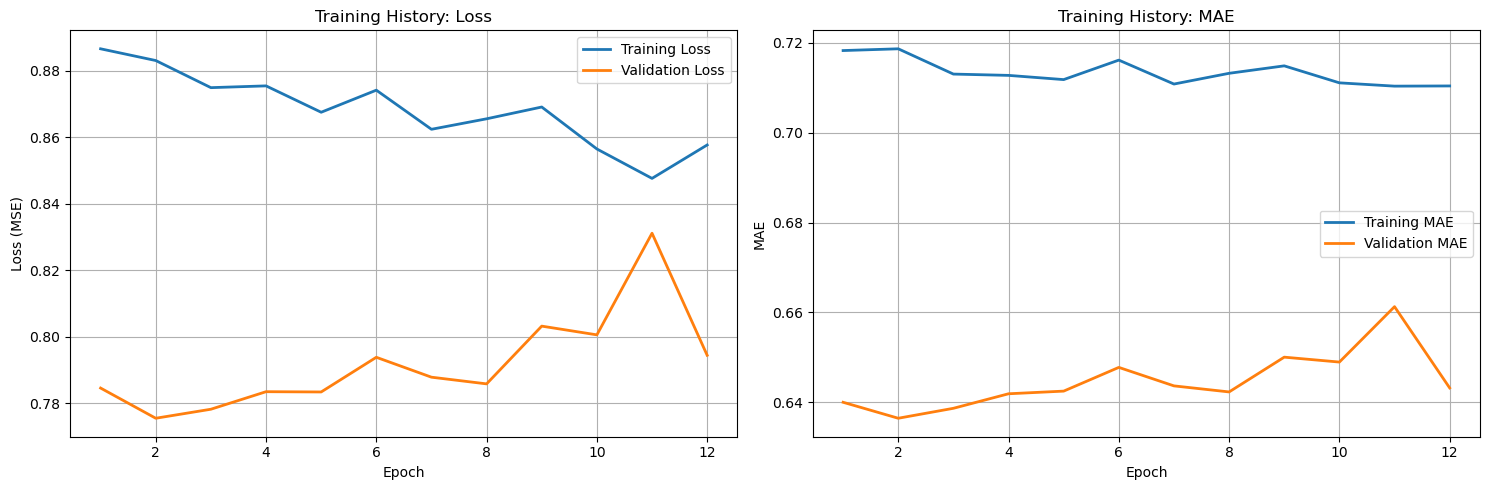

In [9]:
# Plot training history (if we just trained)
if predictor.training_history is not None:
    history_df = predictor.get_training_history()
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    ax1 = axes[0]
    ax1.plot(history_df['epoch'], history_df['loss'], label='Training Loss', linewidth=2)
    ax1.plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title('Training History: Loss')
    ax1.legend()
    ax1.grid(True)
    
    # MAE
    ax2 = axes[1]
    ax2.plot(history_df['epoch'], history_df['mae'], label='Training MAE', linewidth=2)
    ax2.plot(history_df['epoch'], history_df['val_mae'], label='Validation MAE', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MAE')
    ax2.set_title('Training History: MAE')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
else:
    print("Model was loaded from disk, no training history available.")

## 4. Test on Full Test Period

In [10]:
# Generate predictions on test data
print("Generating predictions on test data...")
predictions = predictor.predict(test_data)

print(f"\nPredictions generated for {len(predictions)} time points")
print(f"Columns: {predictions.columns.tolist()}")
predictions.head(10)

Generating predictions on test data...

Predictions generated for 392 time points
Columns: ['actual_price', 'pred_price_1', 'pred_price_2', 'pred_price_3', 'pred_price_4', 'pred_price_5', 'pred_price_6', 'pred_price_7', 'pred_price_8', 'pred_price_9', 'pred_price_10']

Predictions generated for 392 time points
Columns: ['actual_price', 'pred_price_1', 'pred_price_2', 'pred_price_3', 'pred_price_4', 'pred_price_5', 'pred_price_6', 'pred_price_7', 'pred_price_8', 'pred_price_9', 'pred_price_10']


,actual_price,pred_price_1,pred_price_2,pred_price_3,pred_price_4,pred_price_5,pred_price_6,pred_price_7,pred_price_8,pred_price_9,pred_price_10
timestamp,,,,,,,,,,,
2024-05-24 04:00:00+00:00,518.272766,514.839233,509.015717,496.988342,479.268524,456.922791,431.258881,403.584198,375.052704,346.591553,318.887085
2024-05-28 04:00:00+00:00,518.634949,510.561554,497.307404,482.034851,468.008881,457.654480,452.545410,453.635406,461.523865,476.670319,499.541290
2024-05-29 04:00:00+00:00,515.003174,508.406921,498.638153,490.747101,485.305450,482.423218,481.977203,483.739014,487.443817,492.825745,499.635498
2024-05-30 04:00:00+00:00,511.586792,501.260742,485.457703,469.709137,456.552826,448.198975,446.282562,451.952148,466.088684,489.523102,523.205261
2024-05-31 04:00:00+00:00,516.246338,495.397736,478.483490,461.955963,446.998322,434.584442,425.390717,419.819611,418.068756,420.204132,426.219604
2024-06-03 04:00:00+00:00,516.667297,496.026489,475.100922,456.245056,441.184113,430.624969,424.615753,422.871521,424.980804,430.511627,439.055573
2024-06-04 04:00:00+00:00,517.244812,503.183960,500.685699,509.789673,530.138428,561.081238,601.877991,651.757935,709.938416,775.638184,848.095032
2024-06-05 04:00:00+00:00,523.392395,509.359924,506.411194,507.756256,512.926636,521.526367,533.198914,547.620667,564.503113,583.596741,604.693726
2024-06-06 04:00:00+00:00,523.382568,522.440857,531.451721,550.186646,577.538086,612.072327,652.230957,696.430847,743.142517,790.962463,838.676147


In [11]:
# Evaluate performance
print("Evaluating model performance...")
metrics = predictor.evaluate(test_data)
print("\nPerformance Metrics by Prediction Step:")
print(metrics)

Evaluating model performance...

Performance Metrics by Prediction Step:
                MAE        RMSE       MAPE  Direction_Accuracy
step_1    24.069926   32.659734   4.171059           54.731458
step_2    49.743592   68.686163   8.626677           54.731458
step_3    78.301236  109.799004  13.588289           55.242967
step_4   110.137368  157.048202  19.128197           54.219949
step_5   145.544910  211.768160  25.301752           55.498721
step_6   185.419439  275.501905  32.264285           54.987212
step_7   230.064812  350.078576  40.075130           56.010230
step_8   280.809278  437.809397  48.970157           57.033248
step_9   339.243910  541.824458  59.236629           55.498721
step_10  406.552042  666.581827  71.087543           56.010230

Performance Metrics by Prediction Step:
                MAE        RMSE       MAPE  Direction_Accuracy
step_1    24.069926   32.659734   4.171059           54.731458
step_2    49.743592   68.686163   8.626677           54.731458
step

## 5. Visualize Predictions

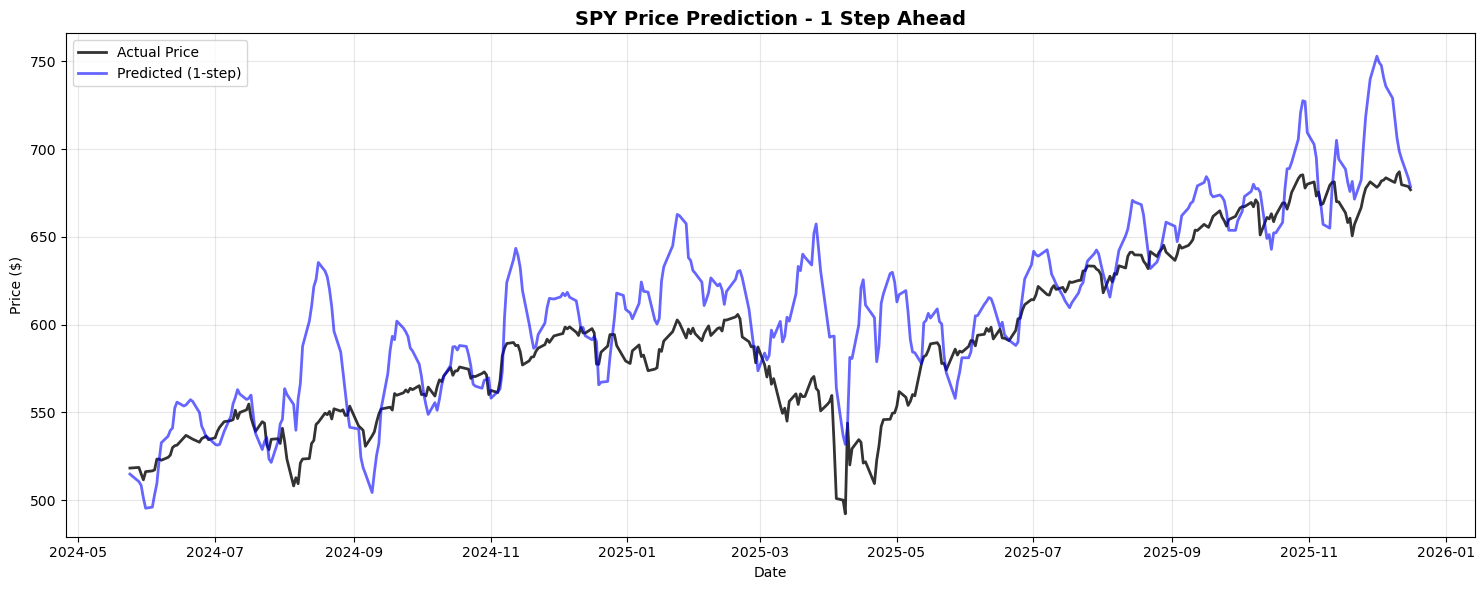

In [12]:
# Plot: Actual vs Predicted (1-step ahead)
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(predictions.index, predictions['actual_price'], 
        label='Actual Price', linewidth=2, color='black', alpha=0.8)
ax.plot(predictions.index, predictions['pred_price_1'], 
        label='Predicted (1-step)', linewidth=2, color='blue', alpha=0.6)

ax.set_title(f'{SYMBOL} Price Prediction - 1 Step Ahead', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

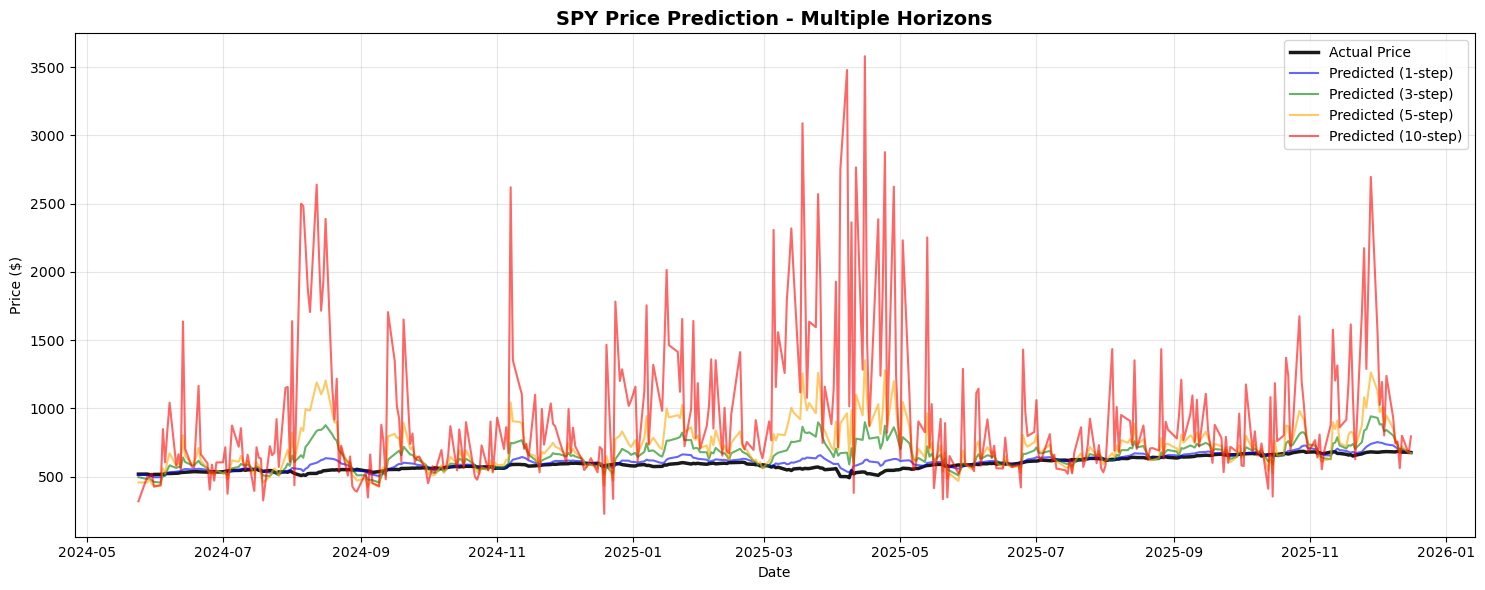

In [13]:
# Plot: Multiple prediction horizons
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(predictions.index, predictions['actual_price'], 
        label='Actual Price', linewidth=2.5, color='black', alpha=0.9)

# Plot different prediction steps with varying opacity
steps_to_plot = [1, 3, 5, 10] if PREDICTION_HORIZON >= 10 else list(range(1, PREDICTION_HORIZON + 1))
colors = ['blue', 'green', 'orange', 'red']

for i, step in enumerate(steps_to_plot):
    if step <= PREDICTION_HORIZON:
        ax.plot(predictions.index, predictions[f'pred_price_{step}'],
               label=f'Predicted ({step}-step)', linewidth=1.5, 
               color=colors[i % len(colors)], alpha=0.6)

ax.set_title(f'{SYMBOL} Price Prediction - Multiple Horizons', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

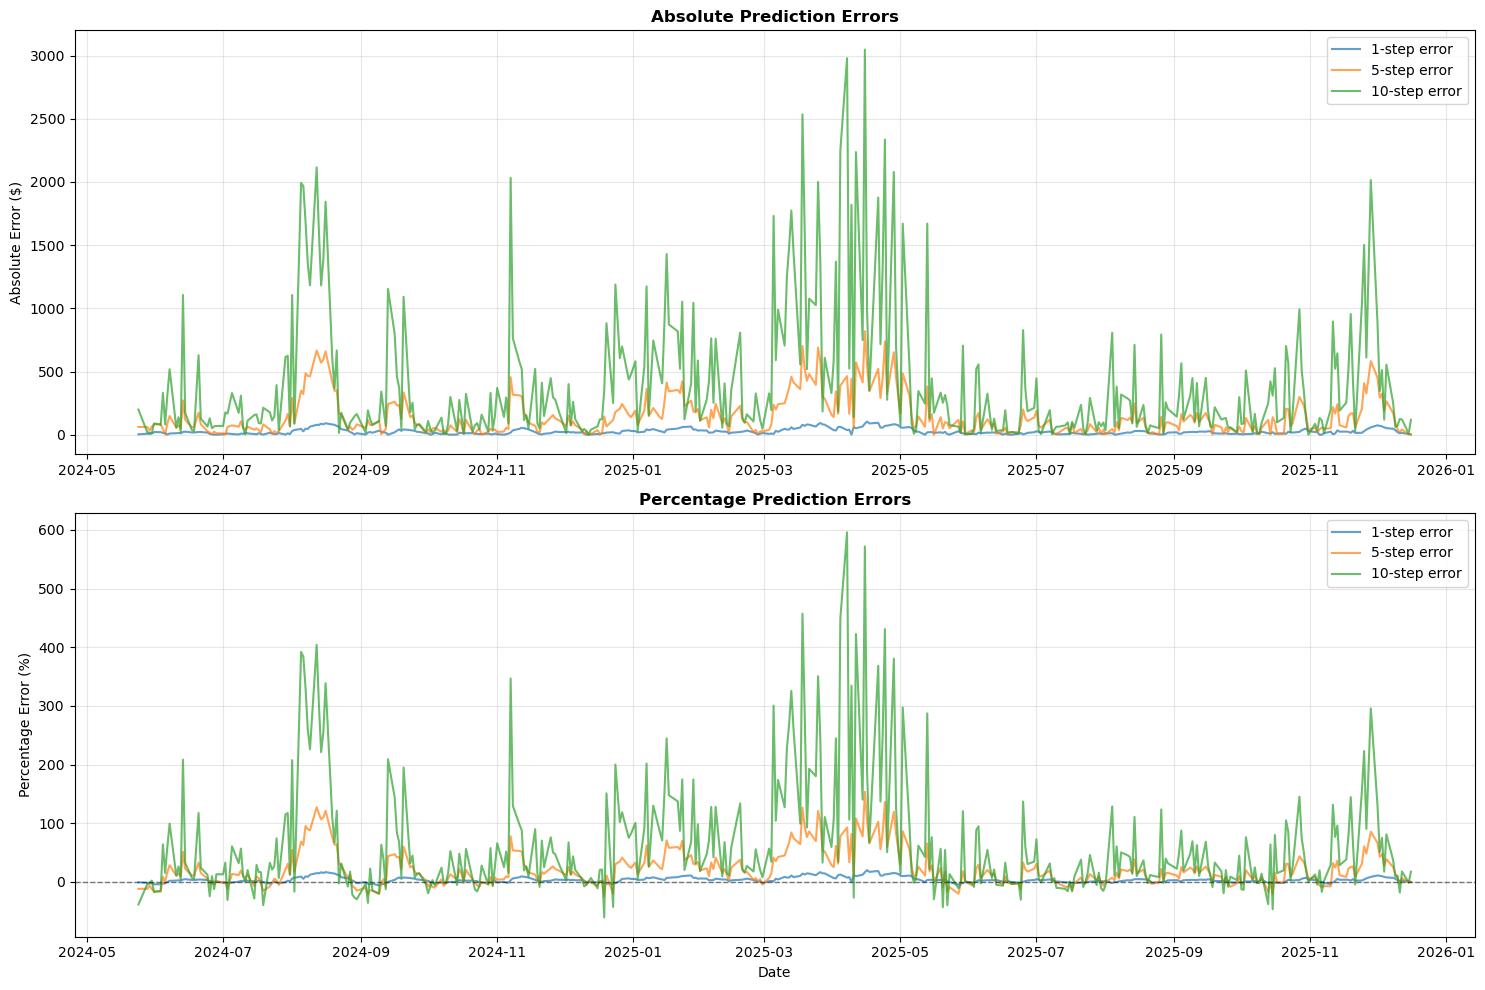

In [14]:
# Plot: Prediction errors over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Absolute errors
ax1 = axes[0]
for step in [1, 5, 10]:
    if step <= PREDICTION_HORIZON:
        errors = np.abs(predictions['actual_price'] - predictions[f'pred_price_{step}'])
        ax1.plot(predictions.index, errors, label=f'{step}-step error', alpha=0.7)

ax1.set_title('Absolute Prediction Errors', fontsize=12, fontweight='bold')
ax1.set_ylabel('Absolute Error ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Percentage errors
ax2 = axes[1]
for step in [1, 5, 10]:
    if step <= PREDICTION_HORIZON:
        pct_errors = (predictions[f'pred_price_{step}'] - predictions['actual_price']) / predictions['actual_price'] * 100
        ax2.plot(predictions.index, pct_errors, label=f'{step}-step error', alpha=0.7)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_title('Percentage Prediction Errors', fontsize=12, fontweight='bold')
ax2.set_ylabel('Percentage Error (%)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Monthly Performance Analysis

In [15]:
# Analyze performance by month
predictions['year_month'] = predictions.index.to_period('M')

monthly_metrics = []

for period in predictions['year_month'].unique():
    month_data = predictions[predictions['year_month'] == period]
    
    if len(month_data) > 0:
        # Calculate metrics for 1-step prediction
        actual = month_data['actual_price'].values
        pred = month_data['pred_price_1'].values
        
        mae = np.mean(np.abs(actual - pred))
        rmse = np.sqrt(np.mean((actual - pred) ** 2))
        mape = np.mean(np.abs((actual - pred) / actual)) * 100
        
        monthly_metrics.append({
            'period': str(period),
            'n_days': len(month_data),
            'mae': mae,
            'rmse': rmse,
            'mape': mape
        })

monthly_df = pd.DataFrame(monthly_metrics)
print("\nMonthly Performance (1-step predictions):")
print(monthly_df.to_string(index=False))


Monthly Performance (1-step predictions):
 period  n_days       mae      rmse      mape
2024-05       5  9.855566 11.504529  1.911382
2024-06      19 13.221525 15.164649  2.497688
2024-07      22  7.657726  8.799975  1.411174
2024-08      22 51.661345 58.083203  9.638358
2024-09      20 23.603281 26.196344  4.269179
2024-10      23  7.874260  9.257435  1.383519
2024-11      20 21.979025 28.180717  3.750636
2024-12      21 15.328381 18.000198  2.600130
2025-01      20 39.371490 41.624278  6.667994
2025-02      19 19.787588 21.637564  3.318299
2025-03      21 53.682789 59.820427  9.601399
2025-04      21 62.834712 67.168417 11.868163
2025-05      21 24.193816 30.237507  4.263597
2025-06      20 10.627649 12.414808  1.776966
2025-07      22 10.309959 12.818301  1.659168
2025-08      21 13.226972 16.223631  2.076944
2025-09      21 15.707121 17.365830  2.407017
2025-10      23 16.773329 20.821825  2.493224
2025-11      19 21.352783 25.451252  3.183549
2025-12      12 38.203796 45.930544  

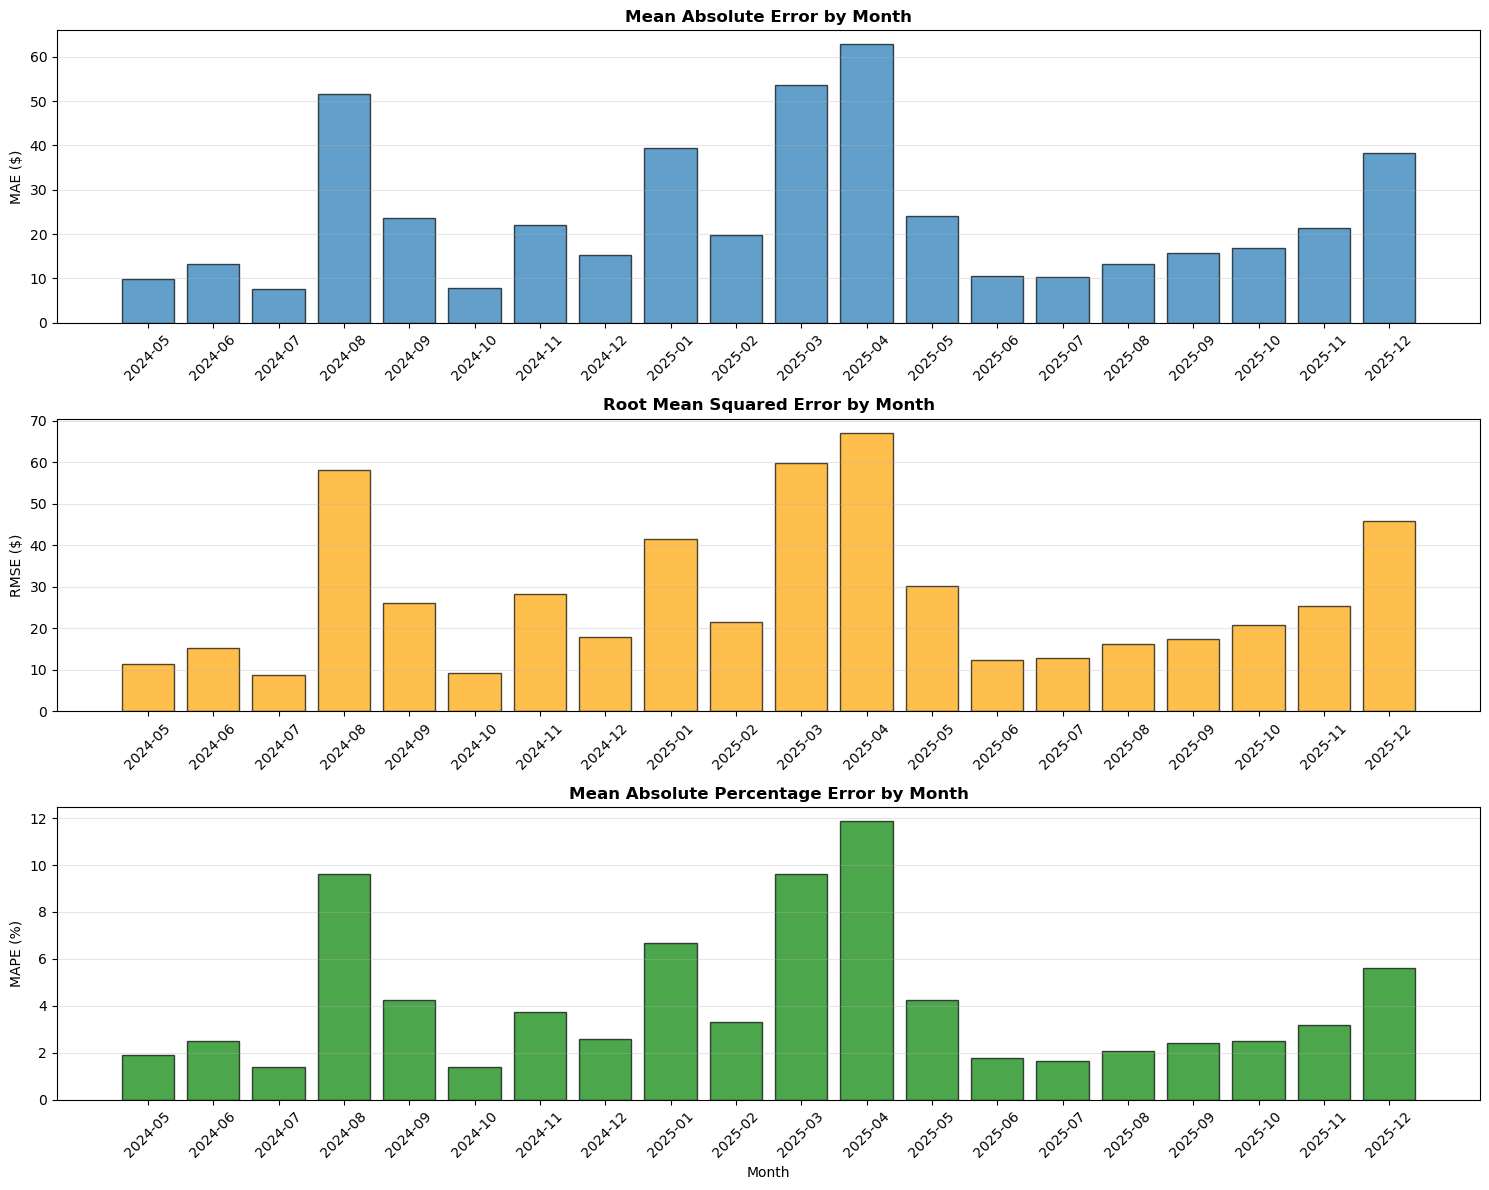

In [16]:
# Visualize monthly performance
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# MAE by month
ax1 = axes[0]
ax1.bar(range(len(monthly_df)), monthly_df['mae'], alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(monthly_df)))
ax1.set_xticklabels(monthly_df['period'], rotation=45)
ax1.set_title('Mean Absolute Error by Month', fontweight='bold')
ax1.set_ylabel('MAE ($)')
ax1.grid(True, axis='y', alpha=0.3)

# RMSE by month
ax2 = axes[1]
ax2.bar(range(len(monthly_df)), monthly_df['rmse'], alpha=0.7, edgecolor='black', color='orange')
ax2.set_xticks(range(len(monthly_df)))
ax2.set_xticklabels(monthly_df['period'], rotation=45)
ax2.set_title('Root Mean Squared Error by Month', fontweight='bold')
ax2.set_ylabel('RMSE ($)')
ax2.grid(True, axis='y', alpha=0.3)

# MAPE by month
ax3 = axes[2]
ax3.bar(range(len(monthly_df)), monthly_df['mape'], alpha=0.7, edgecolor='black', color='green')
ax3.set_xticks(range(len(monthly_df)))
ax3.set_xticklabels(monthly_df['period'], rotation=45)
ax3.set_title('Mean Absolute Percentage Error by Month', fontweight='bold')
ax3.set_ylabel('MAPE (%)')
ax3.set_xlabel('Month')
ax3.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Zoom into Specific Months

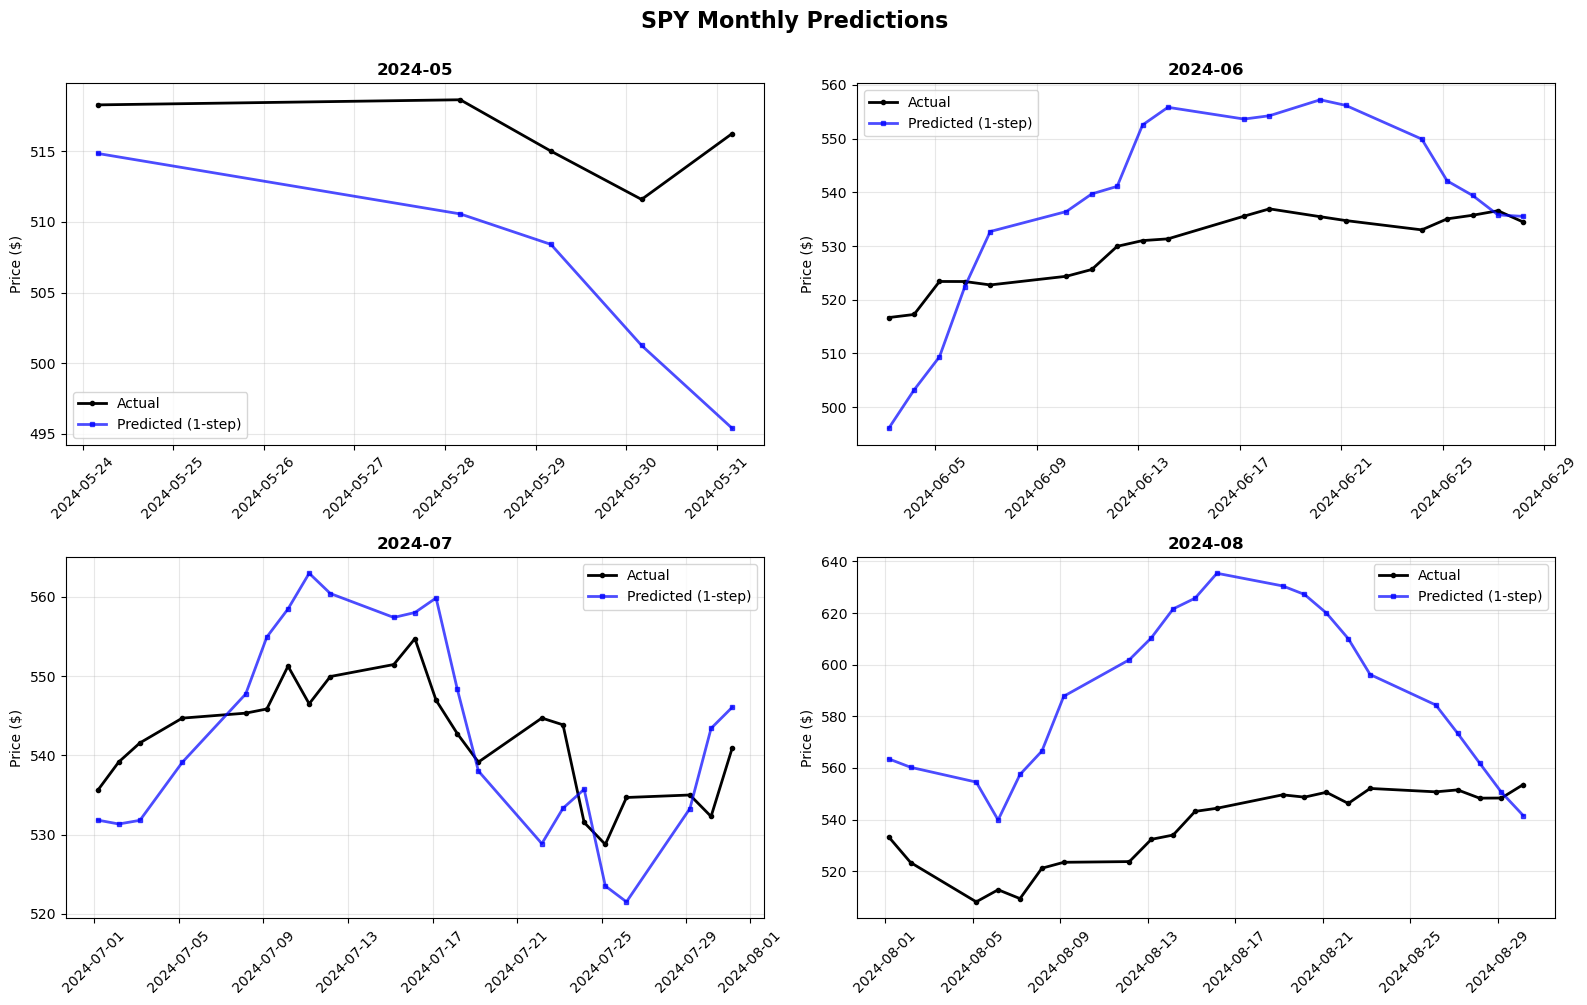

In [17]:
# Select a few months to visualize in detail
months_to_plot = predictions['year_month'].unique()[:4]  # First 4 months

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, period in enumerate(months_to_plot):
    if i >= len(axes):
        break
    
    month_data = predictions[predictions['year_month'] == period]
    
    ax = axes[i]
    ax.plot(month_data.index, month_data['actual_price'], 
           label='Actual', linewidth=2, color='black', marker='o', markersize=3)
    ax.plot(month_data.index, month_data['pred_price_1'], 
           label='Predicted (1-step)', linewidth=2, color='blue', marker='s', markersize=3, alpha=0.7)
    
    ax.set_title(f'{period}', fontweight='bold')
    ax.set_ylabel('Price ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'{SYMBOL} Monthly Predictions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [18]:
# Overall summary
print("="*60)
print("OVERALL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nSymbol: {SYMBOL}")
print(f"Training Period: {TRAIN_START} to {TRAIN_END}")
print(f"Testing Period: {TEST_START} to {TEST_END}")
print(f"\nModel Configuration:")
print(f"  Lookback Window: {LOOKBACK_WINDOW} candles")
print(f"  Prediction Horizon: {PREDICTION_HORIZON} candles")
print(f"  LSTM Units: {LSTM_UNITS}")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Prediction Mode: {PREDICTION_MODE}")
print(f"\nTest Period Statistics:")
print(f"  Total trading days: {len(predictions)}")
print(f"  Months evaluated: {len(monthly_df)}")
print(f"\nAverage Monthly Performance (1-step):")
print(f"  MAE: ${monthly_df['mae'].mean():.2f}")
print(f"  RMSE: ${monthly_df['rmse'].mean():.2f}")
print(f"  MAPE: {monthly_df['mape'].mean():.2f}%")
print(f"\nBest Month: {monthly_df.loc[monthly_df['mae'].idxmin(), 'period']} (MAE: ${monthly_df['mae'].min():.2f})")
print(f"Worst Month: {monthly_df.loc[monthly_df['mae'].idxmax(), 'period']} (MAE: ${monthly_df['mae'].max():.2f})")
print("="*60)

OVERALL PERFORMANCE SUMMARY

Symbol: SPY
Training Period: 2023-01-01 to 2024-12-31
Testing Period: 2024-01-01 to 2025-12-31

Model Configuration:
  Lookback Window: 100 candles
  Prediction Horizon: 10 candles
  LSTM Units: 50
  Layers: 2
  Prediction Mode: recursive

Test Period Statistics:
  Total trading days: 392
  Months evaluated: 20

Average Monthly Performance (1-step):
  MAE: $23.86
  RMSE: $27.34
  MAPE: 4.12%

Best Month: 2024-07 (MAE: $7.66)
Worst Month: 2025-04 (MAE: $62.83)


## Next Steps

**Experiment Ideas:**
1. Try `prediction_mode='direct'` and compare results
2. Adjust `LOOKBACK_WINDOW` (50, 150, 200)
3. Change `PREDICTION_HORIZON` to test different forecasting lengths
4. Increase `LSTM_UNITS` or `NUM_LAYERS` for more capacity
5. Test on different symbols (NVDA, AAPL, etc.)
6. Implement walk-forward retraining (Option B)